# Retail Store Demand Forecasting
## Introduction

This project focuses on analyzing and forecasting retail store inventory and product demand using historical sales data. The goal is to develop predictive models that accurately estimate future demand, which can significantly enhance:

- Inventory management
- Reduction of stockouts and overstocking
- Operational efficiency across retail networks

# Table of Contents

| S.No | Project Topic                         | Description                                                                                          |
|------|--------------------------------------|------------------------------------------------------------------------------------------------------|
| 1    | [Project Objectives](#1.Project-Objectives) | Define the main goals and objectives of the project.                                                 |
| 2    | [Describe the Dataset](#2.Describe-the-Dataset) | Review the [dataset](https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting) from Kaggle.com. |
| 3    | [Data Cleaning and Preparation](#3.Data-Cleaning-and-Preparation) | Prepare and clean the dataset for further analysis and modeling.                                     |
| 4    | [Data Analysis And Visualization](#4.Data-Analysis)      | Perform statistical analysis and visualization on the dataset.                                       |
| 5    | [Model Selection](#5.Model-Selection)  | Select appropriate machine learning models for the project.                                          |
| 6    | [Model Analysis and Prediction](#6.Model-Analysis-And-Prediction) | Train and test the selected model(s) and evaluate performance.                                       |
| 7    | [Conclusion](#7.Conclusion)            | Summarize the findings and insights from the project.                                                |
| 8    | [Appendix](#8.Appendix)                | Include supplementary material, such as code snippets or additional details.                         |
| 9    | [Contributions](#9.Contributions)      | List the contributors to the project.                                                                |


---















## 1.Project Objectives

This project focuses on analyzing and forecasting retail store inventory and product demand using historical sales data. The dataset includes transaction-level records of various items across multiple stores. The main objective is to build predictive models that accurately forecast future demand, enabling better inventory management, reducing stockouts and overstocking, and ultimately improving operational efficiency.


## 2.Describe the Dataset

In this section, we will explore the dataset and provide a detailed description of its structure, features, and contents. For this project, we have used a dataset from Kaggle: **[Retail Store Inventory and Demand Forecasting](https://www.kaggle.com/datasets/atomicd/retail-store-inventory-and-demand-forecasting)**. The dataset has been downloaded and stored in this project repository [**sales_data**](./dataset/sales_data.csv)

### 2.1 Load the dataset

In [4]:
import pandas as pd
sales_df = pd.read_csv('./dataset/sales_data.csv')

### 2.2 Data Observatons

The dataset includes 76,000 records with both categorical and numerical features, essential for understanding demand patterns and forecasting. Below is a description of each variable:

In [6]:
sales_df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [7]:
sales_df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


<span style="color:Red">**Key Observations** </span>.
 - Total number of columns:  
 - Total number of rows:
 - Features , category and description:
 - .....


## 3.Data Cleaning and Preparation

In this section, we will load the dataset, examine its structure, and perform any necessary cleaning or adjustments to ensure the data is suitable for analysis.

From the `sales_df.describe()` output we observer the categorical features like Store ID, Product ID, Category, Region, Weather Condition, etc were removed. This is because pandas library will only process numberic features. So handle the categorical data we should encode the data.


Using pandas Dataframe info() method, Summarize the **sales_df** Dataframe.

In [11]:
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  object 
 1   Store ID            76000 non-null  object 
 2   Product ID          76000 non-null  object 
 3   Category            76000 non-null  object 
 4   Region              76000 non-null  object 
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  object 
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  object 
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: f

Using this output, We can answer the questions related to the dataset. 
- What are the different data types ?
- Are there any missing observations ie row values are empty ?
- Can we drop some irrelevaent features ?
- Is any data conversion requeired ?

### 3.1 Data Types:
The **sales_df.info()** output shows there are mixed Data Types:
  - 7 numerical columns **(int64, float64)** — suitable for statistical modeling.
  - 7 categorical columns **(object)** — Need encoding (Label/One-Hot) for machine learning models.
  - Column **0** is **Date** but the data type is object, it should be converted.


### 3.2 Handling missing data: 

The **sales_df.info()** output shows there are no missing values. All the columns have 76,000 non-null values. 
We can also use pandas **isnull()** function to check number of missing values in the dataset for each columne. 

In [15]:
sales_df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

There are **no missing values** in this DataFrame.
However, if there were **missing or null values**, they can be handled in various ways depending on the situation. Some common methods include:

- Dropping missing data — removing rows or columns containing null values.
- Filling missing data based on data type:
- For numerical data: Replace missing values with the mean, median, or mode.
- For categorical data: Replace missing values with the mode (the most frequent category).
- Forward fill or backward fill — propagate values from previous or next observations.
- Interpolation — estimate missing values based on surrounding data points.

### 3.3 Drop irrelevant columns. 
- Few of the columns like **Store ID** and **Product ID** may not contirbute to prediction.
- Also columns like **Units Sold** and **Units Ordered** is directly depends on the demand and vice versa.
- <span style="color:Red">We can consider dropping these columns.</span>


In [18]:
## Dropping Irrelevant Columns
drop_cols = ['Store ID', 'Product ID', 'Units Sold', 'Units Ordered']  # Irrelevant or data leakage
sales_df.drop(columns=drop_cols, inplace=True)
sales_df.head()

,Date,Category,Region,Inventory Level,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,Electronics,North,195,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,Clothing,North,117,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,Clothing,North,247,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,Electronics,North,139,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,Groceries,North,152,54.41,0,Snowy,0,51.63,Winter,0,59


### 3.4 Encoding the categorical features:
The categorical features are not suitable for statestical analysis. To handle the categorical data, we hot-encode the categorical data.

In [20]:
## Encoding the Categorical Features:
cat_features = ['Category', 'Region', 'Weather Condition', 'Seasonality']
sales_df = pd.get_dummies(sales_df, columns=cat_features, drop_first=True)
sales_df.head()

,Date,Inventory Level,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand,Category_Electronics,Category_Furniture,...,Category_Toys,Region_North,Region_South,Region_West,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,195,72.72,5,0,85.73,0,115,True,False,...,False,True,False,False,False,True,False,False,False,True
1,2022-01-01,117,80.16,15,1,92.02,0,229,False,False,...,False,True,False,False,False,True,False,False,False,True
2,2022-01-01,247,62.94,10,1,60.08,0,157,False,False,...,False,True,False,False,False,True,False,False,False,True
3,2022-01-01,139,87.63,10,0,85.19,0,52,True,False,...,False,True,False,False,False,True,False,False,False,True
4,2022-01-01,152,54.41,0,0,51.63,0,59,False,False,...,False,True,False,False,False,True,False,False,False,True


### 3.5 Data Convertion:

The **Data** column is of type "object", it should be converted to time-series data.

In [22]:
if 'Date' in sales_df.columns:
    sales_df['Date'] = pd.to_datetime(sales_df['Date'])
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 21 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   Date                     76000 non-null  datetime64[ns]
 1   Inventory Level          76000 non-null  int64         
 2   Price                    76000 non-null  float64       
 3   Discount                 76000 non-null  int64         
 4   Promotion                76000 non-null  int64         
 5   Competitor Pricing       76000 non-null  float64       
 6   Epidemic                 76000 non-null  int64         
 7   Demand                   76000 non-null  int64         
 8   Category_Electronics     76000 non-null  bool          
 9   Category_Furniture       76000 non-null  bool          
 10  Category_Groceries       76000 non-null  bool          
 11  Category_Toys            76000 non-null  bool          
 12  Region_North             76000 n

In [23]:
sales_df.head()

,Date,Inventory Level,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand,Category_Electronics,Category_Furniture,...,Category_Toys,Region_North,Region_South,Region_West,Weather Condition_Rainy,Weather Condition_Snowy,Weather Condition_Sunny,Seasonality_Spring,Seasonality_Summer,Seasonality_Winter
0,2022-01-01,195,72.72,5,0,85.73,0,115,True,False,...,False,True,False,False,False,True,False,False,False,True
1,2022-01-01,117,80.16,15,1,92.02,0,229,False,False,...,False,True,False,False,False,True,False,False,False,True
2,2022-01-01,247,62.94,10,1,60.08,0,157,False,False,...,False,True,False,False,False,True,False,False,False,True
3,2022-01-01,139,87.63,10,0,85.19,0,52,True,False,...,False,True,False,False,False,True,False,False,False,True
4,2022-01-01,152,54.41,0,0,51.63,0,59,False,False,...,False,True,False,False,False,True,False,False,False,True


## 4.Data Analysis And Visulization

#### 4.1 Correlation Martix
Correlation analysis is used to measure and understand the strength and direction of a relationship between two quantitative variables. 
Correlation values range from -1 to 1.
- +1: Perfect positive linear relationship
- -1: Perfect Negative linear relationship
- 0: No linear relationship.

In [26]:
# Data Analysis And Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Matrix
corr_matrix = sales_df.corr()

# Print correlation of important numerical features with 'Demand'
corr_with_demand = corr_matrix['Demand'].sort_values(ascending=False)
print("Correlation of features with Demand:\n", corr_with_demand)

Correlation of features with Demand:
 Demand                     1.000000
Category_Groceries         0.289628
Promotion                  0.282537
Discount                   0.224723
Weather Condition_Sunny    0.152096
Inventory Level            0.126618
Seasonality_Summer         0.102753
Region_South               0.027912
Region_North              -0.009484
Seasonality_Winter        -0.011986
Date                      -0.014310
Competitor Pricing        -0.023036
Price                     -0.023461
Region_West               -0.039202
Category_Electronics      -0.053744
Seasonality_Spring        -0.079597
Weather Condition_Snowy   -0.090734
Category_Toys             -0.100603
Weather Condition_Rainy   -0.107263
Category_Furniture        -0.306625
Epidemic                  -0.363661
Name: Demand, dtype: float64


#### 4.2 Correlation Heatmap

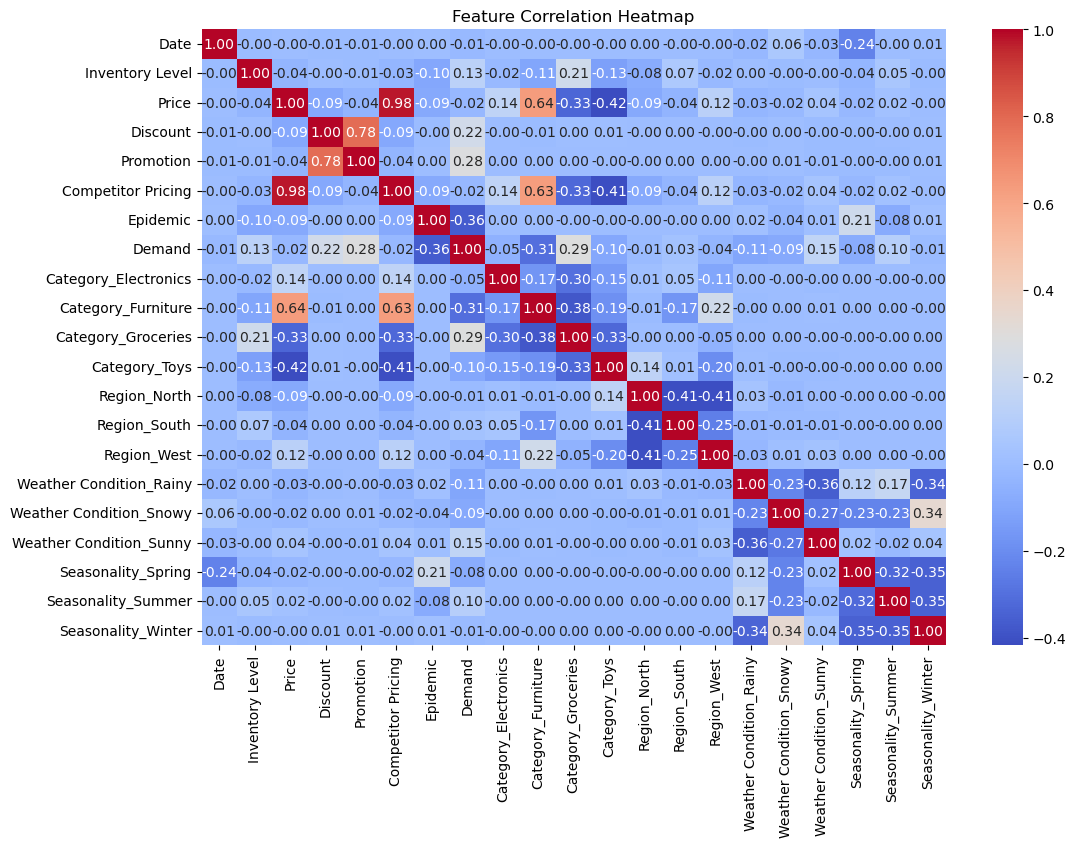

In [28]:
# Correlation Heatmap (Prepared but not shown)
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

**Observations**

Based on the analysis of the correlation matrix and the corresponding heatmap, we can draw the following conclusions:


**Top Positively Correlated Features with Demand:**

| Feature                      | Correlation | Interpretation                                                       |
| ---------------------------- | ----------- | -------------------------------------------------------------------- |
| **Category\_Groceries**      | +0.2896     | When the product is Groceries, Demand tends to be higher.            |
| **Promotion**                | +0.2825     | Promotion **increases demand** significantly — logical in retail.    |
| **Discount**                 | +0.2247     | Higher discounts associate with higher demand — expected effect.     |
| **Weather Condition\_Sunny** | +0.1521     | Demand slightly higher on sunny days — minor positive effect.        |
| **Inventory Level**          | +0.1266     | More stock means potential for higher demand — though low influence. |
| **Seasonality\_Summer**      | +0.1027     | Slightly higher demand in summer — depends on product type.          |

**Top Negatively Correlated Features with Demand:**

| Feature                      | Correlation | Interpretation                                                              |
| ---------------------------- | ----------- | --------------------------------------------------------------------------- |
| **Epidemic**                 | **-0.3637** | Strongest negative effect — demand **drops during epidemic periods**.       |
| **Category\_Furniture**      | **-0.3066** | Furniture items tend to have **lower demand compared to other categories**. |
| **Weather Condition\_Rainy** | -0.1073     | Slight demand reduction on rainy days.                                      |
| **Category\_Toys**           | -0.1006     | Toys see lower demand in this dataset context.                              |
| **Seasonality\_Spring**      | -0.0796     | Slightly lower demand during spring season.                                 |
| **Region\_West**             | -0.0392     | Slightly lower demand in Western region.                                    |


We will now focus on analyzing the relationship between features that show positive correlation with demand.

#### 4.3 Distribution of Demand

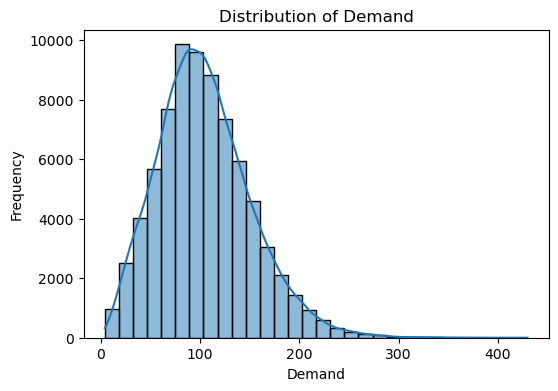

In [33]:
# Distribution of Target Variable 'Demand'
plt.figure(figsize=(6,4))
sns.histplot(sales_df['Demand'], kde=True, bins=30)
plt.title('Distribution of Demand')
plt.xlabel('Demand')
plt.ylabel('Frequency')
plt.show()

**<u>Observations</u>:**
- The histogram of Demand shows a right-skewed distribution. There are few outliners causing long right-skewed distribution.
- Most demand values are concentrated between 50 and 150 units.
- Mode of the distribution is around 90 to 100. 

#### 4.4 Demand by Seasonality

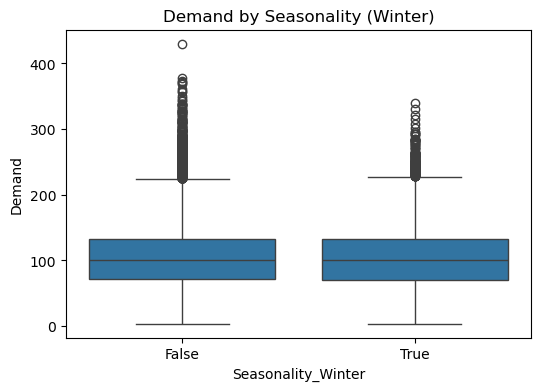

In [36]:
# Boxplot: Demand by Seasonality
if 'Seasonality_Winter' in sales_df.columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='Seasonality_Winter', y='Demand', data=sales_df)
    plt.title('Demand by Seasonality (Winter)')
    plt.show()

**<u>Observation</u>:**

- **False** = Non-Winter Season and **True** = Winter Season.
- Both box plot show similar median demand , around 100. and the spread (25th to 75th percentile) is similar for both groups.
- This suggests that, on average demand remains almost the same wheather it is winter or not.
- Both groups have a significant number of high outliers.(above 200) and are similar. This suggest high demands are also not depends on the winter season.
- **Conclusion** : Seasonality (Winter) does not have a strong influence on product demand based on this boxplot.
- We should check other features like **price** , **promption** or **inventory level**. 

#### 4.5 Relationship between price and Demand

Lets do a scatterplot to plot the relation between Price and Demand.

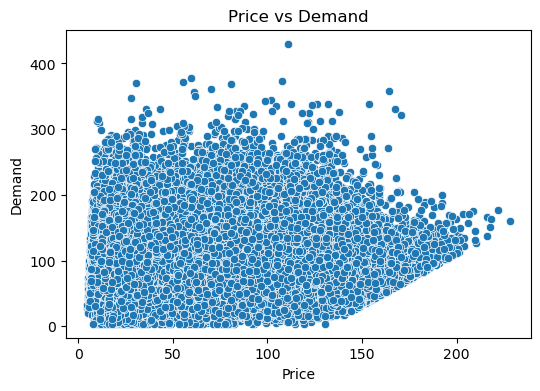

In [39]:
# Relationship between Price and Demand
plt.figure(figsize=(6,4))
sns.scatterplot(x='Price', y='Demand', data=sales_df)
plt.title('Price vs Demand')
plt.xlabel('Price')
plt.ylabel('Demand')
plt.show()

**<u>Observation</u>:**

- The plot shows as the price is increased the demand tends to decrease.
- **Heteroscedasticity:** The spread of demand varies across price levels - there is wider range of demand at lower prices and a narrower range at higher prices.
- So the plot does not show very linear relationship between Price and Demand.
- This is non-constant varaince, which is important for **linear regression**

#### 4.6 Relationship between Discount and Demand

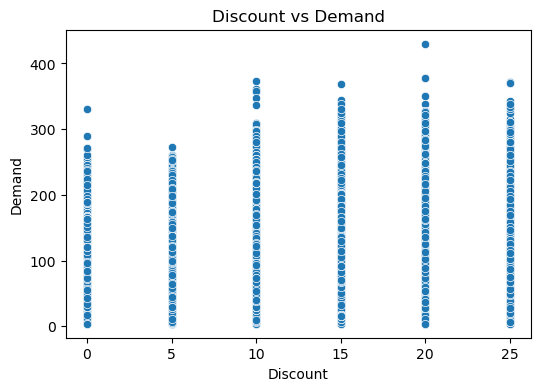

In [42]:
# Relationship between Discount and Demand
plt.figure(figsize=(6,4))
sns.scatterplot(x='Discount', y='Demand', data=sales_df)
plt.title('Discount vs Demand')
plt.xlabel('Discount')
plt.ylabel('Demand')
plt.show()

**<u>Observation</u>:**
- The discount variables has discrete values - 0,5,10,15,20,25. Each indicating the discount percentage.
- There is upward shift in the maximum demand as discounts increase.
- Higher discounts seems to be associated with more frequent high-demand outcomes.
- At every discount level, the demand shows large variability from 0 to 300 plus. **This implies that discount alone does not fully explain the demand**. There could be other variables influencing demand.

#### 4.6 Region distribution

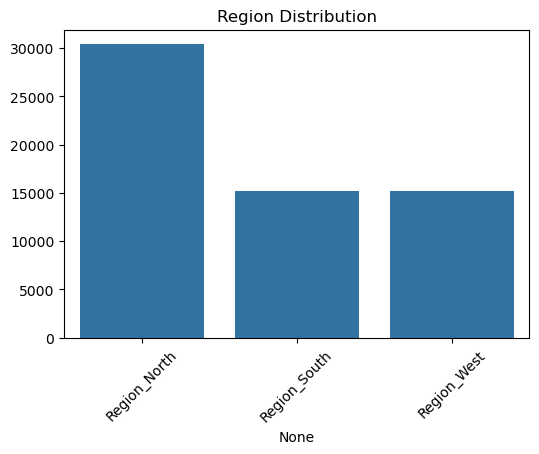

In [45]:
# Countplot: Region Distribution (if region dummies exist)
region_cols = [col for col in sales_df.columns if 'Region_' in col]
if region_cols:
    region_counts = sales_df[region_cols].sum()
    plt.figure(figsize=(6,4))
    sns.barplot(x=region_counts.index, y=region_counts.values)
    plt.title('Region Distribution')
    plt.xticks(rotation=45)
    plt.show()

**<u>Observation:</u>**

- Region North dominates the recorded observations.(30,000)
- Region South and North are balanced.(15,000 each)
- If we are condering Region to build the model with this dataset. Then the results could be biased as Region_North has more observations.
- The plot suggests the Region North is a large market area, may be capital city.  This can be used for business strategy.

#### 4.7 Time Series Plot: Demand over Time 


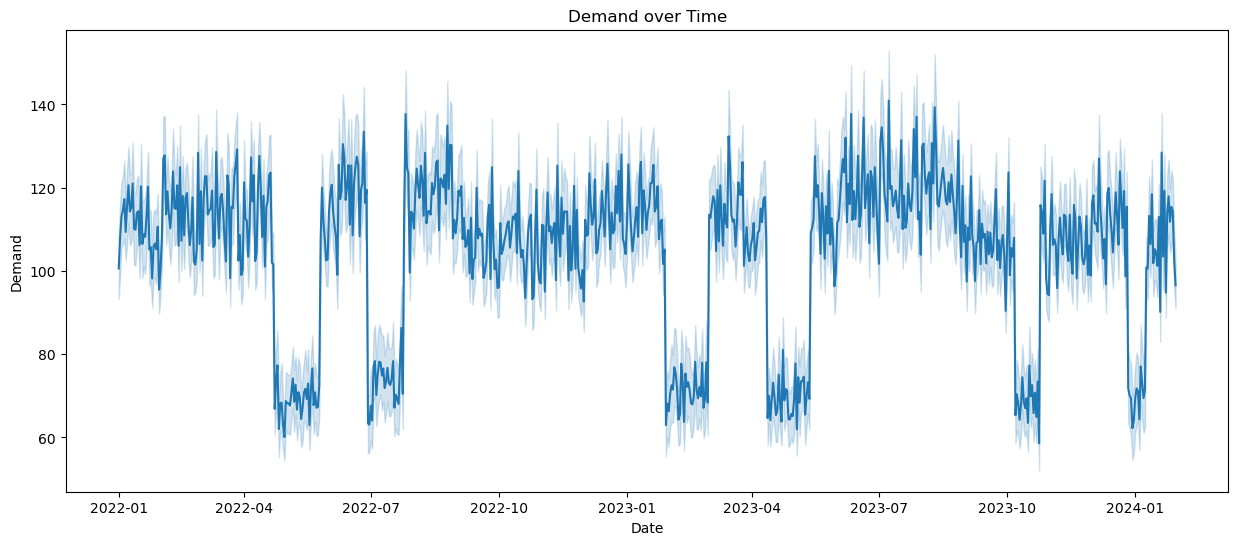

In [48]:
if 'Date' in sales_df.columns:
    plt.figure(figsize=(15,6))
    sns.lineplot(x='Date', y='Demand', data=sales_df)
    plt.title('Demand over Time')
    plt.xlabel('Date')
    plt.ylabel('Demand')
    plt.show()

**<u>Observation:</u>**

- There is unclear long-term upward or downward trend in the demand over the entire period.
- However, the plot shows periodicity. i.e, There are **high demand periods** and **low demand periods**.
- The high demand periods are around **July-August** months. The demands are between 110 to 140.
- There are few low demand periods Jan-Feb 2023 and 2024. and also around Apr-May 2022 and 2023. The demands are between 60 and 80.
- This shows predictible yearly cycle in demand.
- In summary, the plot illustrates a demand pattern driven primarily by strong yearly seasonality, with demand consistently higher in the mid-year months and lower at the beginning of the year and late spring/early summer. There are also smaller, higher-frequency variations throughout the year.

#### 4.8 OLS Regressioin with Statsmodels.

We use Ordinary Least Square to check p-values for each feature.

In [64]:
import statsmodels.api as sm

# Define features and target
X = sales_df.drop(['Demand','Date'], axis=1)
y = sales_df['Demand']
X.dtypes   

Inventory Level              int64
Price                      float64
Discount                     int64
Promotion                    int64
Competitor Pricing         float64
Epidemic                     int64
Category_Electronics          bool
Category_Furniture            bool
Category_Groceries            bool
Category_Toys                 bool
Region_North                  bool
Region_South                  bool
Region_West                   bool
Weather Condition_Rainy       bool
Weather Condition_Snowy       bool
Weather Condition_Sunny       bool
Seasonality_Spring            bool
Seasonality_Summer            bool
Seasonality_Winter            bool
dtype: object

In [66]:
# We need to convert all the bool values to 0 and 1.
for col in X.select_dtypes(include='bool').columns:
    X[col] = X[col].astype(int)
X.dtypes

Inventory Level              int64
Price                      float64
Discount                     int64
Promotion                    int64
Competitor Pricing         float64
Epidemic                     int64
Category_Electronics         int32
Category_Furniture           int32
Category_Groceries           int32
Category_Toys                int32
Region_North                 int32
Region_South                 int32
Region_West                  int32
Weather Condition_Rainy      int32
Weather Condition_Snowy      int32
Weather Condition_Sunny      int32
Seasonality_Spring           int32
Seasonality_Summer           int32
Seasonality_Winter           int32
dtype: object

In [68]:
# Add constant (intercept term)
X_const = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_const).fit()

# Summary to view p-values
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Demand   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.442
Method:                 Least Squares   F-statistic:                     3167.
Date:                Wed, 18 Jun 2025   Prob (F-statistic):               0.00
Time:                        22:47:34   Log-Likelihood:            -3.7823e+05
No. Observations:               76000   AIC:                         7.565e+05
Df Residuals:                   75980   BIC:                         7.567e+05
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      76.4505      0.720    106.229      0.000      75.040      77.861
Inventory Level             0.0036      0.001      6.103      0.000       0.002       0.005
Price                       0.3265      0.015     21.256      0.000       0.296       0.357
Discount                    0.3005      0.028     10.846      0.000       0.246       0.355
Promotion                  26.0775      0.438     59.600      0.000      25.220      26.935
Competitor Pricing          0.0723      0.014      4.990      0.000       0.044       0.101
Epidemic                  -39.0216      0.332   -117.592      0.000     -39.672     -38.371
Category_Electronics      -19.7197      0.497    -39.712      0.000     -20.693     -18.746
Category_Furniture        -60.0764      0.518   -116.061      0.000     -61.091     -59.062
Category_Groceries         15.7939      0.400     39.511      0.000      15.010      16.577
Category_Toys              -2.0695      0.537     -3.855      0.000      -3.122      -1.017
Region_North                1.7980      0.352      5.113      0.000       1.109       2.487
Region_South               -2.9552      0.407     -7.262      0.000      -3.753      -2.158
Region_West                 1.8587      0.421      4.419      0.000       1.034       2.683
Weather Condition_Rainy    -9.3475      0.360    -25.980      0.000     -10.053      -8.642
Weather Condition_Snowy    -9.5909      0.431    -22.259      0.000     -10.435      -8.746
Weather Condition_Sunny     9.8761      0.323     30.540      0.000       9.242      10.510
Seasonality_Spring          2.5389      0.386      6.579      0.000       1.783       3.295
Seasonality_Summer          8.9628      0.378     23.682      0.000       8.221       9.705
Seasonality_Winter          2.1509      0.370      5.813      0.000       1.426       2.876
==============================================================================
Omnibus:                     2826.992   Durbin-Watson:                   1.982
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             4573.596
Skew:                           0.338   Prob(JB):                         0.00
Kurtosis:                       3.994   Cond. No.                     2.82e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.82e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**<u>Obeservation</u>:**

- R-squared = 0.442 : **Indicates Moderate fit**. This means approximately 44.2% of the variance in 'Demand' can be explyained by the independent variables in this model.
- Prob (F-statistic) = 000 : **Indicates the rejection of the null hypothesis**. At least one of independent variables is a **significant predictor of Demand**. This means the model as a whole is statistically significant.
- **P-values** : All the p-values for individual coefficients are 0.00, which means all the independent variables in the model are statistically significant.
- **key coefficients:**
    - **Inventory Level = 0.0036** : For every one unit increase in Inventory level, Demand increases by 0.0036. This is very **small positive effect.**
    - **Price = 0.3265** : For every one-unit increase in 'Price', 'Demand' is estimated to increase by 0.3265 units, holding other factors constant. This could be rather revers, **The price increase when demand goes high.**. This feature can be ignored.
    - **Discount = 0.3005** : This is as expected as **discounts typically boost demand.**
    - **Promotion = 26.0775** : This shows very strong positive effect.
    - **Competitor Pricing = 0.0723**: This suggests that as competitors raise their prices, your demand slightly increases.
    - **Weather Condition_Sunny = 9.8761**: Higher compared to Rainy and snowy weather conditions.
    - **Seasonality_Summer = 8.9628**: High compared to Winter and Spring. Suggest strong positive seasonal effect.

**<u>Conclusion:</u>**

- Promotion has the largest positive impact on demand.
- Seasonality_Summer and Weather Condition_Sunny significantly boost demand.
- Epidemic and Category_Furniture have the largest negative impacts.

## 5.Model Selection
Choose a suitable machine learning model for the project.

## 6.Model Analysis And Prediction

## 7.Conclusion

## 8.Appendix

## 9.Contributions
- [Jagdish Mane](https://www.linkedin.com/in/jagdish-mane/)
- [Sachine Shukla](https://www.linkedin.com/in/sks336/)
- [Hanmant Kattimani](https://www.linkedin.com/in/hanmant-kattimani-b8323741/)